In [1]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

In [2]:
model = ChatGroq(model="llama-3.1-8b-instant")

In [3]:
class SentimentSchema(BaseModel):
    sentiment: Literal["pos", "neg"] = Field(description="Sentiment of the review")

In [4]:
class DiagonosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description="The Category of the reveiw")
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description="The emotional tone expressed by the user")
    urgency: Literal["low", "medium", "high"] = Field(description="How urgent or critical the issue appears to be")

In [5]:
structured_model_1 = model.with_structured_output(SentimentSchema)
structured_model_2 = model.with_structured_output(DiagonosisSchema)

In [6]:
structured_model_1.invoke("This is a good phone").sentiment

'pos'

In [7]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["pos", "neg"]
    diagnosis: dict
    response: str

In [8]:
def find_sentiment(state: ReviewState):
    prompt = f"For the following review find out the sentiment \n {state["review"]}"
    sentiment = structured_model_1.invoke(prompt).sentiment
    return {"sentiment": sentiment}

In [9]:
def check_sentiment(state: ReviewState):
    if state["sentiment"] == "pos":
        return "positive_response"
    else:
        return "run_diagnosis"

In [10]:
def negative_response(state: ReviewState):
    diagnosis = state["diagnosis"]
    prompt = f"""You are a suport assistant. \n The user had a {diagnosis["issue_type"]} issue, sounded {diagnosis["tone"]} and marked urgency as {diagnosis["urgency"]}.\n Write an emphathetic, helpful message"""
    response = model.invoke(prompt).content
    return {"response": response}

In [11]:
def positive_response(state: ReviewState):
    prompt = f"Write a thankful message on this review: {state["review"]}"
    response = model.invoke(prompt).content
    return {"response": response}

In [12]:
def run_diagnosis(state: ReviewState):
    prompt = f"""Diagnose this negative review: {state["review"]}\n Return the issue_type, tone and urgency."""
    response = structured_model_2.invoke(prompt)
    return {"diagnosis": response.model_dump()}

In [13]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)
graph.add_node("positive_response", positive_response)

graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_sentiment, {"run_diagnosis": "run_diagnosis", "positive_response": "positive_response"})
graph.add_edge("run_diagnosis", "negative_response")
graph.add_edge("negative_response", END)
graph.add_edge("positive_response", END)

workflow = graph.compile()

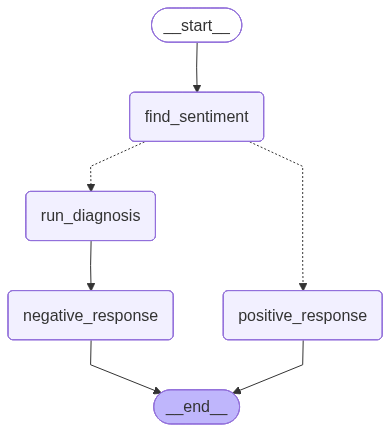

In [14]:
workflow

In [15]:
initial_state = {
    "review": "I have been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

final_state = workflow.invoke(initial_state)

In [16]:
final_state

{'review': 'I have been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'neg',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': "I'm so sorry to hear that you're experiencing a frustrating issue and that it's affecting you urgently. I can imagine how frustrating it must be to deal with bugs and errors, especially when you're on a deadline or trying to accomplish something important.\n\nPlease know that I'm here to help you as soon as possible, and I'll do my best to resolve the issue quickly and efficiently. Can you please provide me with more details about the bug you're experiencing, such as:\n\n* What exactly is happening (e.g., error messages, functionality not working as expected)\n* When did the issue start (e.g., after a specific action, update, or event)\n